In [4]:
from msi.msi import MSI
from diff_prof.diffusion_profiles import DiffusionProfiles
import multiprocessing
import numpy as np
import pickle
import networkx as nx
import polars as pl
import gc
import seaborn as sns
import matplotlib.pyplot as plt

from filter_logic import filter_drug_protein_edges
from tests.msi import test_msi
from tests.diff_prof import test_diffusion_profiles

In [8]:
DRUG_COL = 'drugbank_id'
TGT_COL = 'uniprot_id'
LABEL_COL = 'sample_type'  # positive / negative_balanced
PAIR_COL = 'compound_target_pair'

In [9]:
df_lazy = pl.scan_parquet("data/combined_filtered_annotated_docking_results.parquet")

In [6]:
def _pair_best_score(df_in: pl.DataFrame, score_col: str, best: str) -> pl.DataFrame:
    if score_col not in df_in.columns:
        print(f"Warning: column not found, skipping: {score_col}")
        return pl.DataFrame()

    if best not in {"min", "max"}:
        raise ValueError("best must be 'min' or 'max'")

    agg_score = (pl.min(score_col) if best == "min" else pl.max(score_col)).alias(score_col)

    return (
        df_in
        .filter(pl.col(score_col).is_not_null() & pl.col(score_col).is_finite())
        .group_by(PAIR_COL)
        .agg([
            pl.first(DRUG_COL).alias(DRUG_COL),
            pl.first(TGT_COL).alias(TGT_COL),
            pl.first(LABEL_COL).alias(LABEL_COL),
            agg_score,
        ])
    )

In [10]:
df_gnina  = _pair_best_score(df_lazy, "GNINA_Score",  best="min").collect()


/tmp/ipykernel_66745/2228018867.py:2: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if score_col not in df_in.columns:


In [ ]:
df_smina  = _pair_best_score(df_lazy, "SMINA_Score",  best="min").collect()


In [ ]:
df_ledock = _pair_best_score(df_lazy, "Ledock_Score", best="min").collect()


In [ ]:
df_gold   = _pair_best_score(df_lazy, "GOLD_Score",   best="max").collect()


In [5]:
df_DeepDTA = _pair_best_score(df_lazy, "dta_DeepDTA_ic50", best="max").collect()
df_GAT_GCN = _pair_best_score(df_lazy, "dta_GAT_GCN_ic50", best="max").collect()
df_GCNNet = _pair_best_score(df_lazy, "dta_GCNNet_ic50", best="max").collect()
df_GINConvNet = _pair_best_score(df_lazy, "dta_GINConvNet_ic50", best="max").collect()
df_MLTLE_GCN = _pair_best_score(df_lazy, "dta_MLTLE_GCN_ic50", best="max").collect()
df_MLTLE_GIN = _pair_best_score(df_lazy, "dta_MLTLE_GIN_ic50", best="max").collect()


/tmp/ipykernel_2995/2228018867.py:2: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if score_col not in df_in.columns:


In [ ]:
print("Pair-level rows:",
      {"GNINA": df_gnina.height, "SMINA": df_smina.height, "LEDOCK": df_ledock.height, "GOLD": df_gold.height},
      {"DeepDTA": df_DeepDTA.height, "GAT_GCN": df_GAT_GCN.height, "GCNNet": df_GCNNet.height,
       "GINConvNet": df_GINConvNet.height, "MLTLE_GCN": df_MLTLE_GCN.height, "MLTLE_GIN": df_MLTLE_GIN.height})

In [11]:
# Load your dataframes efficiently
df_edges = pl.read_csv("data/1_drug_to_protein.tsv", separator="\t")
df_mapping = pl.read_csv("data/uniprot_gene_mapping.csv")

# Run the filter
filtered_edges = filter_drug_protein_edges(
    df_edges, 
    df_mapping, 
    df_gnina, 
    score_column='GNINA_Score', 
    better='lower', 
    score_cutoff=-8  # Example cutoff
)

# Save or use (e.g. for MSI)
#filtered_edges.write_csv("data/1_drug_to_protein_filtered.tsv", separator="\t")

In [9]:
filtered_edges

node_1,node_2,node_1_type,node_2_type,node_1_name,node_2_name,score
str,i64,str,str,str,str,f32
"""DB00675""",2100,"""drug""","""protein""","""tamoxifen""","""ESR2""",7.325947
"""DB12010""",4921,"""drug""","""protein""","""fostamatinib""","""DDR2""",7.377819
"""DB00323""",1312,"""drug""","""protein""","""Tolcapone""","""COMT""",5.64182
"""DB00476""",6531,"""drug""","""protein""","""duloxetine""","""SLC6A3""",6.075935
"""DB12010""",2050,"""drug""","""protein""","""fostamatinib""","""EPHB4""",7.292631
…,…,…,…,…,…,…
"""DB00657""",1139,"""drug""","""protein""","""mecamylamine""","""CHRNA7""",5.804764
"""DB08896""",673,"""drug""","""protein""","""regorafenib""","""BRAF""",6.410345
"""DB00315""",3351,"""drug""","""protein""","""zolmitriptan""","""HTR1B""",7.160933


In [8]:
percentage = df_GAT_GCN["drugbank_id"].is_in(filtered_edges["node_1"]).mean() * 100
percentage

/tmp/ipykernel_2995/3841314282.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  percentage = df_GAT_GCN["drugbank_id"].is_in(filtered_edges["node_1"]).mean() * 100


82.80968581148689

In [9]:
filtered_edges.to_pandas().to_csv("data/1_drug_to_protein_filtered_GAT_GCN.tsv", sep="\t", index=False)

In [ ]:
# Wrapper usage: build MSI + recompute ALL diffusion profiles
# Note: this recomputes profiles for every drug/indication and can take a while.
from diff_prof import compute_all_diffusion_profiles_for_msi, diffusion_profile_similarity

# Example A: default MSI files (same as MSI())
profiles_default, msi_default = compute_all_diffusion_profiles_for_msi(
        save_load_file_path="results/",
        num_cores=12,
 )

# Example B: use a filtered drug→protein TSV (e.g., your GAT_GCN-filtered edges)
profiles_gat, msi_gat = compute_all_diffusion_profiles_for_msi(
    drug2protein_file_path="data/1_drug_to_protein_filtered_GAT_GCN.tsv",
    save_load_file_path="results_gat_gcn/",
    num_cores=12,
 )

[Wrapper] DB01098 default vs filtered: similarity=0.989832, dist=0.0102729, n_common=28847
[Wrapper] DB01098 vs DB00401: similarity=0.709071, dist=0.410296


In [2]:
# Parallel similarity computation: default MSI vs filtered MSI (per drug)
import multiprocessing as mp
import numpy as np
import pandas as pd

# Restrict to drugs present in BOTH graphs AND both profile dicts
drugs_default = set(msi_default.drugs_in_graph)
drugs_gat = set(msi_gat.drugs_in_graph)
common_drugs = sorted((drugs_default & drugs_gat) & set(profiles_default.keys()) & set(profiles_gat.keys()))
print(f"Common drugs to compare: {len(common_drugs)}")

# Precompute intersection-node indices ONCE (shared by all drugs)
common_nodes = [n for n in msi_default.nodelist if n in msi_gat.node2idx]
if len(common_nodes) == 0:
    raise ValueError("No common nodes between MSI graphs; cannot compare profiles")

idx_a = np.fromiter((msi_default.node2idx[n] for n in common_nodes), dtype=np.int64)
idx_b = np.fromiter((msi_gat.node2idx[n] for n in common_nodes), dtype=np.int64)
n_common = int(len(common_nodes))
print(f"Common nodes for alignment: {n_common}")

# Use fork on Linux so the large profile dicts are shared copy-on-write
ctx = mp.get_context("fork")
num_workers = max(1, int(mp.cpu_count() * 0.6))
num_workers = min(num_workers, len(common_drugs) if len(common_drugs) > 0 else 1)
print(f"Using workers: {num_workers}")

# Globals for worker processes (inherited via fork)
_P_DEFAULT = profiles_default
_P_GAT = profiles_gat
_IDX_A = idx_a
_IDX_B = idx_b

def _similarity_one_drug(drug_id: str):
    a = _P_DEFAULT[drug_id][_IDX_A]
    b = _P_GAT[drug_id][_IDX_B]
    dist = float(np.linalg.norm(a - b, ord=2))
    sim = 1.0 / (1.0 + dist)
    norm_a = float(np.linalg.norm(a, ord=2))
    norm_b = float(np.linalg.norm(b, ord=2))
    rel_dist = dist / (norm_a + 1e-12)
    sum_a = float(np.sum(a))
    sum_b = float(np.sum(b))
    return (drug_id, sim, dist, rel_dist, norm_a, norm_b, sum_a, sum_b)

if len(common_drugs) == 0:
    df_similarity_default_vs_filtered = pd.DataFrame(
        columns=[
            "drug_id","similarity_l2","l2_distance","relative_l2_distance","l2_norm_default","l2_norm_filtered","sum_default","sum_filtered","n_common_nodes"
        ]
    )
else:
    with ctx.Pool(processes=num_workers) as pool:
        # chunksize tuned to reduce overhead for large drug lists
        chunksize = max(1, len(common_drugs) // (num_workers * 8) if num_workers else 1)
        rows = list(pool.imap_unordered(_similarity_one_drug, common_drugs, chunksize=chunksize))
    df_similarity_default_vs_filtered = pd.DataFrame(
        rows,
        columns=[
            "drug_id","similarity_l2","l2_distance","relative_l2_distance","l2_norm_default","l2_norm_filtered","sum_default","sum_filtered"
        ],
    )
    df_similarity_default_vs_filtered["n_common_nodes"] = n_common
    df_similarity_default_vs_filtered = df_similarity_default_vs_filtered.sort_values("similarity_l2", ascending=False).reset_index(drop=True)

df_similarity_default_vs_filtered.head()

Common drugs to compare: 549
Common nodes for alignment: 28847
Using workers: 7


,drug_id,similarity_l2,l2_distance,relative_l2_distance,l2_norm_default,l2_norm_filtered,sum_default,sum_filtered,n_common_nodes
0,DB00960,0.994812,0.005215,0.021605,0.241388,0.236597,0.987488,1.0,28847
1,DB00834,0.994283,0.005750,0.024135,0.238244,0.232828,0.988162,1.0,28847
2,DB09343,0.994168,0.005866,0.020333,0.288500,0.282755,0.996569,1.0,28847
3,DB01359,0.994113,0.005922,0.023463,0.252382,0.246942,0.986704,1.0,28847
4,DB09123,0.993995,0.006041,0.022926,0.263511,0.258160,0.988006,1.0,28847


<Axes: xlabel='similarity_l2', ylabel='Density'>

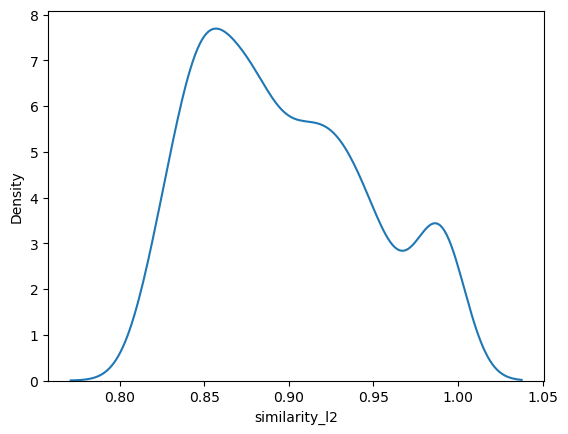

In [5]:
# Plot distributions of similarity_l2 in df_similarity_default_vs_filtered
sns.kdeplot(df_similarity_default_vs_filtered,x='similarity_l2')

In [ ]:
# ------------------------------------------------------------
# Example C: compare profiles returned by compute_all_diffusion_profiles_for_msi
# Same drug (DB01098) across two different MSI graphs -> intersection alignment
sim_wrap, diag_wrap = diffusion_profile_similarity(
    profiles_default["DB01098"],
    profiles_gat["DB01098"],
    method="l2",
    align="intersection",
    msi_a=msi_default,
    msi_b=msi_gat,
    normalization=None,
    return_diagnostics=True,
 )
print(f"[Wrapper] DB01098 default vs filtered: similarity={sim_wrap:.6g}, dist={diag_wrap['l2_distance']:.6g}, n_common={diag_wrap['n_common']}")

In [ ]:

# Two drugs within the SAME returned dict -> position alignment works
other_key_gat = next(k for k in profiles_gat.keys() if k != "DB01098")
sim_same, diag_same = diffusion_profile_similarity(
    profiles_gat["DB01098"],
    profiles_gat[other_key_gat],
    method="l2",
    align="position",
    return_diagnostics=True,
 )
print(f"[Wrapper] DB01098 vs {other_key_gat}: similarity={sim_same:.6g}, dist={diag_same['l2_distance']:.6g}")